# **EDA & Preprocessing - FEVER Dataset**  


FEVER (Fact Extraction and VERification) dataset consists of claims generated by altering sentences extracted from Wikipedia and subsequently verified without knowledge of the sentence they were derived from. The claims are classified as **SUPPORTS**, **REFUTES** or **NOT ENOUGH INFO**.

In [121]:
import pandas as pd
import json, glob, os
from tqdm import tqdm
import pickle
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt

In [122]:
df = pd.read_json('https://drive.google.com/uc?export=download&id=1NjvoUnUNAmVPSse1mhRSKQNbarsMThFA', lines=True)

In [ ]:
df.head()

,id,verifiable,label,claim,evidence
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broa...,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [..."
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271..."
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, s...","[[[255136, 254645, History_of_art, 2]]]"
3,156709,VERIFIABLE,REFUTES,Adrienne Bailon is an accountant.,"[[[180804, 193183, Adrienne_Bailon, 0]]]"
4,83235,NOT VERIFIABLE,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,"[[[100277, None, None, None]]]"


Claims with label "NOT ENOUGH INFO" have no evidences. As they do not contribute to training, we can safely drop the corresponding rows.

In [123]:
df.drop(df[df['label'] == 'NOT ENOUGH INFO'].index, inplace=True)

In [124]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 109810 entries, 0 to 145448
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          109810 non-null  int64 
 1   verifiable  109810 non-null  object
 2   label       109810 non-null  object
 3   claim       109810 non-null  object
 4   evidence    109810 non-null  object
dtypes: int64(1), object(4)
memory usage: 5.0+ MB
None


In [154]:
def count_evidence(evidence):
    if not isinstance(evidence, list):
        return 0
    return sum(len(group) for group in evidence if isinstance(group, list))

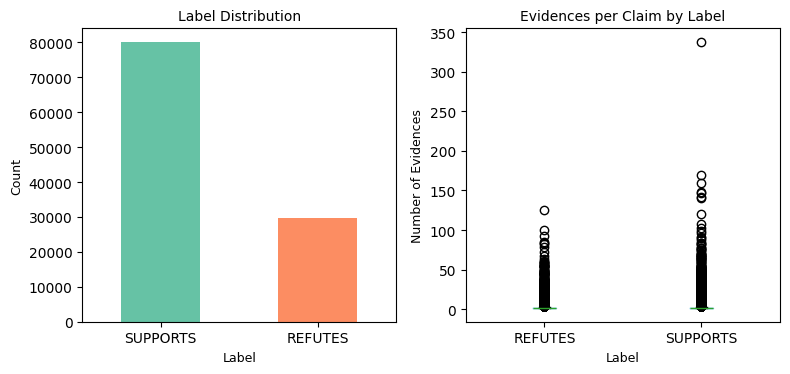

In [155]:
df["num_evidences"] = df["evidence"].apply(count_evidence)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # 1 row, 2 columns

# --- Left: Label distribution ---
df["label"].value_counts().plot(kind="bar", color=["#66c2a5", "#fc8d62", "#8da0cb"],ax=axes[0])
axes[0].set_title("Label Distribution", fontsize=10)
axes[0].set_xlabel("Label", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

# --- Right: Evidence count per label ---
df.boxplot(column="num_evidences",by="label",grid=False,ax=axes[1],color=dict(boxes="skyblue"))
axes[1].set_title("Evidences per Claim by Label", fontsize=10)
axes[1].set_xlabel("Label", fontsize=9)
axes[1].set_ylabel("Number of Evidences", fontsize=9)

# Remove the auto 'Boxplot grouped by label' title
fig.suptitle("")
plt.tight_layout()
plt.show()

The evidence column lists the **Wikipedia** sentences that support or refute each claim. It is structured as nested lists, where each inner list contains items like  
> [annotation_id, evidence_id, page_title, sentence_index]

eg: [92206, 104971, Nikolaj_Coster-Waldau, 7]

Using the [Pre-processed Wikipedia Pages (June 2017 dump)](https://fever.ai/download/fever/wiki-pages.zip), the corresponding claim texts can be extracted.


In [ ]:
!wget https://fever.ai/download/fever/wiki-pages.zip -O wiki-pages.zip
!unzip -q wiki-pages.zip -d wiki-pages

--2025-10-27 08:23:46--  https://fever.ai/download/fever/wiki-pages.zip
Resolving fever.ai (fever.ai)... 3.161.150.40, 3.161.150.110, 3.161.150.98, ...
Connecting to fever.ai (fever.ai)|3.161.150.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1713485474 (1.6G) [application/zip]
Saving to: ‘wiki-pages.zip’

wiki-pages.zip      100%[===================>]   1.60G  33.4MB/s    in 51s     

2025-10-27 08:24:38 (32.0 MB/s) - ‘wiki-pages.zip’ saved [1713485474/1713485474]



In [ ]:
!head -n 3 /content/wiki-pages/wiki-pages/wiki-001.jsonl

{"id": "", "text": "", "lines": ""}
{"id": "1928_in_association_football", "text": "The following are the football -LRB- soccer -RRB- events of the year 1928 throughout the world . ", "lines": "0\tThe following are the football -LRB- soccer -RRB- events of the year 1928 throughout the world .\n1\t"}
{"id": "1986_NBA_Finals", "text": "The 1986 NBA Finals was the championship round of the 1985 -- 86 NBA season . It pitted the Eastern Conference champion Boston Celtics against the Western Conference champion Houston Rockets , in a rematch of the 1981 Finals -LRB- only Allen Leavell and Robert Reid remained from the Rockets ' 1981 team -RRB- . The Celtics defeated the Rockets four games to two to win their 16th NBA championship . The championship would be the Celtics ' last until the 2008 NBA Finals . Larry Bird was named the Finals MVP .   On another note , this series marked the first time the `` NBA Finals '' branding was officially used , as they dropped the `` NBA World Championship S

In [ ]:
def build_wiki_index(wiki_dir):
    """
    Build an index mapping page_name -> file_path for fast lookup.
    """
    index = {}
    for file in tqdm(sorted(glob.glob(os.path.join(wiki_dir, "wiki-*.jsonl")))):
        with open(file, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    index[data["id"]] = file
                except Exception:
                    continue
    print(f"✅ Indexed {len(index)} wiki pages.")
    return index

wiki_index = build_wiki_index("/content/wiki-pages/wiki-pages")
pickle.dump(wiki_index, open("wiki_index.pkl", "wb"))


100%|██████████| 109/109 [00:54<00:00,  1.98it/s]


✅ Indexed 5416537 wiki pages.


In [ ]:
wiki_index = pickle.load(open("wiki_index.pkl", "rb"))

In [50]:
def extract_evidence_sentences_fast_single(row, wiki_index, wiki_dir="wiki-pages"):
    claim, label, evidence = row
    cache = {}  # local cache inside process
    sentences = []

    def load_page(page_name):
        if page_name in cache:
            return cache[page_name]
        file_path = wiki_index.get(page_name)
        if not file_path:
            cache[page_name] = {}
            return {}
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                data = json.loads(line)
                if data["id"] == page_name:
                    lines = {}
                    for l in data["lines"].split("\n"):
                        if "\t" in l:
                            idx, text = l.split("\t", 1)
                            lines[int(idx)] = text
                    cache[page_name] = lines
                    return lines
        cache[page_name] = {}
        return {}

    if not isinstance(evidence, list):
        return {"claim": claim, "evidence_sentences": [], "label": label}

    for group in evidence:
        for ev in group:
            if not isinstance(ev, list) or len(ev) < 4:
                continue
            _, _, page, sent_idx = ev
            if not page or sent_idx is None:
                continue
            wiki_lines = load_page(page)
            if sent_idx in wiki_lines:
                sentences.append(wiki_lines[sent_idx])

    return {"claim": claim, "evidence_sentences": sentences, "label": label}

def build_training_df_sequential(df, wiki_index):
    records = []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Building FEVER", dynamic_ncols=True):
        claim, label, evidence = row.claim, row.label, row.evidence
        res = extract_evidence_sentences_fast_single((claim, label, evidence), wiki_index)
        records.append(res)
    return pd.DataFrame(records)

For each label, sampling 10000 claims thereby a total of 20000 claims. Their evidence texts are extracted from wiki-pages. A new .jsonl file with

> claim, evidence_sentences, label  

columns is created to be used for training the model.


In [150]:
def sample_equal_counts(df, n_per_label, label_col="label", random_state=42):
    sampled_frames = []
    for label_name, group in df.groupby(label_col):
        n = min(n_per_label, len(group))  # handle if one label has fewer
        sampled = group.sample(n=n, random_state=random_state)
        sampled_frames.append(sampled)
    df_sampled = pd.concat(sampled_frames).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df_sampled

# ---- Run it ----
df_filtered = df[df['num_evidences'].between(1,10)]
df_sampled = sample_equal_counts(df_filtered, n_per_label=10000)

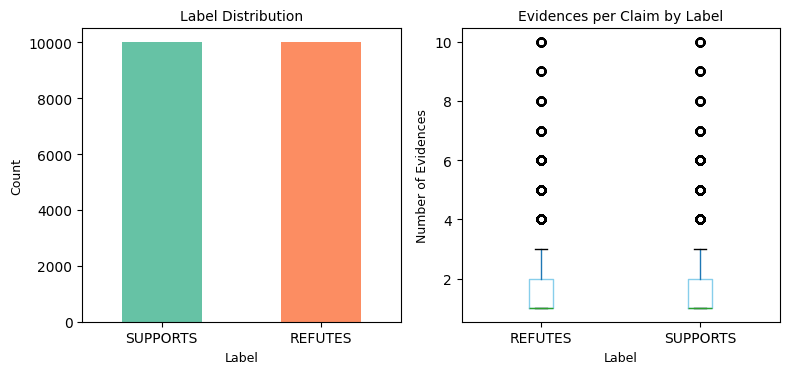

In [153]:
df_sampled["num_evidences"] = df_sampled["evidence"].apply(count_evidence)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# --- Left: Label distribution ---
df_sampled["label"].value_counts().plot(kind="bar", color=["#66c2a5", "#fc8d62", "#8da0cb"],ax=axes[0])
axes[0].set_title("Label Distribution", fontsize=10)
axes[0].set_xlabel("Label", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

# --- Right: Evidence count per label ---
df_sampled.boxplot(column="num_evidences",by="label",grid=False,ax=axes[1],color=dict(boxes="skyblue"))
axes[1].set_title("Evidences per Claim by Label", fontsize=10)
axes[1].set_xlabel("Label", fontsize=9)
axes[1].set_ylabel("Number of Evidences", fontsize=9)

# Remove the auto 'Boxplot grouped by label' title
fig.suptitle("")
plt.tight_layout()
plt.show()


In [156]:
train_df = build_training_df_sequential(df_sampled, wiki_index)
train_df.to_json("fever_train_ready.jsonl", orient="records", lines=True, force_ascii=False)

Building FEVER: 100%|██████████| 20000/20000 [1:07:57<00:00,  4.91it/s]


In [157]:
train_df.head()

,claim,evidence_sentences,label
0,Vladimir Putin studied German.,[Born in Leningrad -LRB- now Saint Petersburg ...,SUPPORTS
1,Burundi is a squid.,[Burundi -LRB- -LSB- bəˈrʊndi -RSB- or -LSB- b...,REFUTES
2,Ronda Rousey's first feature film role was in ...,[Rousey 's first feature film role was the 201...,REFUTES
3,Beautiful People is a film.,[Beautiful People was a British comedy drama t...,REFUTES
4,Richard Nixon defeated George McGovern in 1972.,[He was reelected in one of the largest electo...,SUPPORTS


Evidences are sometimes repeated. Can be!

In [158]:
df[df['claim']=='Vladimir Putin studied German.']

,id,verifiable,label,claim,evidence,num_evidences
26264,222003,VERIFIABLE,SUPPORTS,Vladimir Putin studied German.,"[[[264368, 261842, Vladimir_Putin, 5]], [[2643...",2


## **Data ready to train the model...!!!**